`%matplotlib inline` 是一个 IPython 魔术命令，用于在 Jupyter Notebook 或者 JupyterLab 中显示 matplotlib 图形。当你在 Jupyter Notebook 或 JupyterLab 中使用 matplotlib 绘图时，如果在代码块的最前面加上 `%matplotlib inline`，它会告诉 Jupyter 在 notebook 中内嵌 matplotlib 图形，并在代码块执行后直接显示图形，而不需要调用 `plt.show()` 函数来显示图形。

In [36]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

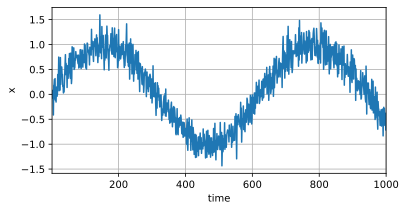

In [37]:
T = 1000 #总共生成1000个点
time = torch.arange(1, T+1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000],figsize=(6, 3))

.reshape(-1,1) 是 NumPy 或者类似库（比如 PyTorch）中的一个方法，用于重新塑造数组的形状。在这个方法中，参数 -1 表示一个占位符，它告诉 NumPy 或者 PyTorch 库根据数组的大小自动计算该轴的长度，而 1 表示希望将数组重新塑造成一个列向量（也就是一个列数为1的二维数组）。

具体来说，.reshape(-1,1) 的作用是将原始数组变形为只有一列的二维数组，其中行数由原始数组的大小决定。这在某些情况下很有用，例如在机器学习中，当你需要将一个多维数组转换为一个列向量时，可以使用 .reshape(-1,1) 来实现这个目标。

In [40]:
tau = 4
features = d2l.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]      
labels = d2l.reshape(x[tau:], (-1, 1))

In [41]:
batch_size, n_train = 16, 600
# 只有前n_train个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

ReLU（Rectified Linear Unit）是一种常用的激活函数，在深度学习中经常被使用。其定义如下：

ReLU(x) = max(0, x)

换句话说，对于输入的任何负值，ReLU 将输出0，对于任何非负值，ReLU 将保持输入值不变。这个函数的图像在原点左侧是一条直线，斜率为0，在原点右侧是一条直线，斜率为1。这种简单的形式使得计算非常高效，并且在许多情况下，ReLU 能够提供良好的性能。

ReLU 激活函数的一个重要特点是它能够缓解梯度消失的问题，因为它在正值区域具有恒定的梯度。此外，ReLU 还有助于加速收敛，减少训练时间。因此，它通常被作为深度神经网络中隐藏层的默认激活函数。

In [42]:
# 初始化网络权重的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

In [43]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()  # 更新参数模型
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.068440
epoch 2, loss: 0.054757
epoch 3, loss: 0.050578
epoch 4, loss: 0.049534
epoch 5, loss: 0.047357


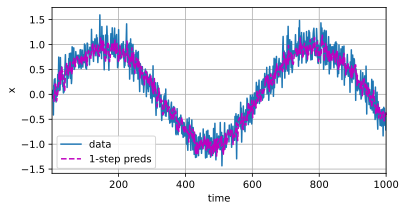

In [50]:
onestep_preds = net(features)  # 输入进去就可以进行一次前向传播
d2l.plot([time, time[tau:]], 
         [d2l.numpy(x), d2l.numpy(onestep_preds)], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], 
         figsize=(6, 3))

在PyTorch中，torch.size()方法和shape属性都用于获取张量的形状信息，但它们有一些细微的区别：

torch.size()方法：

torch.size()是一个函数，用于获取张量的形状信息。
它返回一个包含每个维度大小的元组（或者说是torch.Size对象）。
例如，对于一个形状为(2, 3, 4)的张量，tensor.size()将返回一个包含三个元素的元组 (2, 3, 4)，分别表示张量的三个维度的大小。
shape属性：

shape是一个属性，用于获取张量的形状信息。
它返回一个包含每个维度大小的元组（或者说是torch.Size对象）。
与torch.size()类似，shape属性也提供了张量的形状信息。
这两者的作用是相同的，但是在使用上可能会略有差别。通常来说，torch.size()更适合用于编程时动态获取张量形状的场景，而shape属性更常用于打印或调试时显示张量的形状信息。

In [51]:
multistep_preds = d2l.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        d2l.reshape(multistep_preds[i - tau: i], (1, -1)))

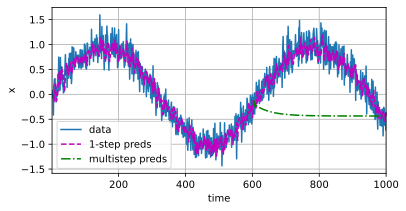

In [52]:
d2l.plot([time, time[tau:], time[n_train + tau:]],
         [d2l.numpy(x), d2l.numpy(onestep_preds),
          d2l.numpy(multistep_preds[n_train + tau:])], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))